<h1>Exercice 1 - Health Expextation</h1>


-> <a href="https://www.machinelearnia.com/school/course/introduction-data-science/lecture/4990758">Lien vers l'énoncé</a>

-> <a href="https://www.machinelearnia.com/school/course/introduction-data-science/lecture/5057896">Lien vers la correction</a>

<h2>Setup</h2>

In [2]:
# Standard libraries 
import pandas as pd

# Visualisation library
import seaborn as sns
import matplotlib.pyplot as plt



<h2>Data</h2>

- `Year`: The year of the recorded observation (ranging from 1970 to 2020).
- `Country`: Name of the country (Canada, France, Germany, Great Britain, Japan, and the USA).
- `Spending_USD`: Per capita health expenditure measured in USD (inflation-adjusted international dollars).
- `Life_Expectancy`: Average life expectancy at birth in years.

In [3]:
# Load data into a DataFrame
df = sns.load_dataset("healthexp")

# Display the 5first rows
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


[ Warning ] : 

Si on travaille sur MacOS et qu'on à ce message d'erreur au chargement des données :
"URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1129)>"

Alors faire : 
"""
If you're using macOS go to Macintosh HD > Applications > Python3.6 folder (or whatever version of python you're using) > double click on "Install Certificates.command" file
"""

Ou faire : 
Supprimer l'environnement actuel avec Python 3.9 et créer un nouvel environnement virtuel avec `uv init --python 3.11` (et si nécessaire `uv venv --python 3.11`)

<h3>Astuces</h3>

In [4]:
# Quick visualisation of our data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    str    
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 8.7 KB


On peut ainsi voir le nombre de lignes (`274 entries, 0 to 273 `) le nombre de colonnes (`total 5 columns`).  On a ensuite un détail sur ces différentes colonnes avec le nombre de valeurs `non-null` et le type de la variable (`int`, `object` comme des \[`str, etc`\], `float`. 
Enfin, cette méthode nous indique également quelle place tout ce DataFrame prend sur notre RAM.

Beaucoup de monde connait cette fonction mais peu de personne l'utilise. Pourtant, c'est un super point de départ. 

Une seconde astuce est d'utiliser la méthode `nunique()` de Pandas. Comme on peut le voir ci-dessous, cela va indiquer le nombre de valeurs unique qu'on va retrouver dans chaque colonne. 

In [5]:
# Count the number of unique value in each column
df.nunique()

Year                51
Country              6
Spending_USD       274
Life_Expectancy    118
dtype: int64

Ici par exemple, on a 6 valeurs unique pour la colonne `Country`.  Cela peut nous aider à déterminer qu'est-ce qui est considéré comme une variable discrète et qu'est ce qui est considéré comme une variable continue. 

Il faut donc retenir ces deux fonctions `nunique()` et `info()`, et les utiliser. !!! 

<h2>Questions et réponses</h2>

<h3>1. <u>Déterminez quelles sont les variables Discrètes et Continues du dataset</u></h3>

Variables discrètes : `Year` et `Country` 

Variables continues : `Spending_USD` et `Life_Expectancy`

<h3>2. <u>Analysez la variable "Country".</u></h3>

Ici, on vient de le voir, `Country` est une variable discrète. On va donc utiliser la méthode `value_counts()` pour calculer les effectifs de chaque catégorie de cette variable. 

In [6]:
# Count the number of individuous within each category
df["Country"].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

On sait donc que la catégorie `Japan` apparaît 51 fois, idem our `USA`, etc. 

La première chose à relever, est que chaque pays n'apparaît pas le même nombre de fois dans notre jeu de donnée. La catégorie `France` est sous représentée par exemple. Il faut donc le garder à l'esprit pour les autres analyses qu'on va faire à la suite. 

Pour mieux appréhender le caractère équilibré ou non du jeu de donnée, il est intéressant d'afficher ces effectifs en terme de proportion du jeu de donnée. 

In [8]:
# Normalize data to get each category proportion from the dataset
df["Country"].value_counts(normalize=True).round(2)

Country
Japan            0.19
USA              0.19
Germany          0.18
Canada           0.16
Great Britain    0.16
France           0.13
Name: proportion, dtype: float64

En plus d'afficher les effectifs, il est important de correctement trier les valeurs et/ou les index. 

In [9]:
# Sort Values 
df["Country"].value_counts().sort_values()

Country
France           35
Great Britain    43
Canada           44
Germany          50
Japan            51
USA              51
Name: count, dtype: int64

Ici les données sont triées par ordre croissant. C'est-à-dire, de la plus petite à la plus grande. 

In [10]:
# Sort index 
df["Country"].value_counts().sort_index()

Country
Canada           44
France           35
Germany          50
Great Britain    43
Japan            51
USA              51
Name: count, dtype: int64

<Axes: xlabel='Country'>

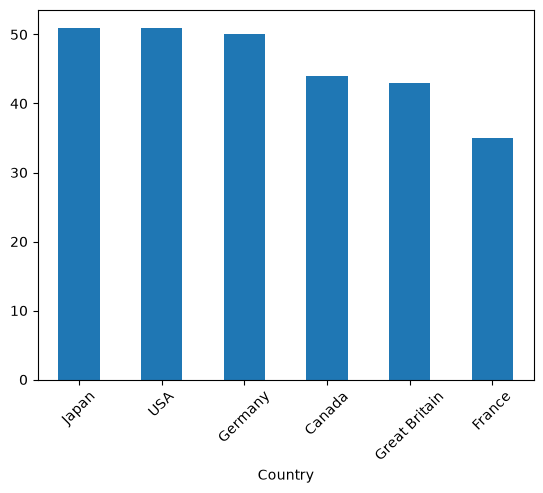

In [12]:
# Dispay those numbers within a chart 
df["Country"].value_counts().plot(kind="bar", rot=45)

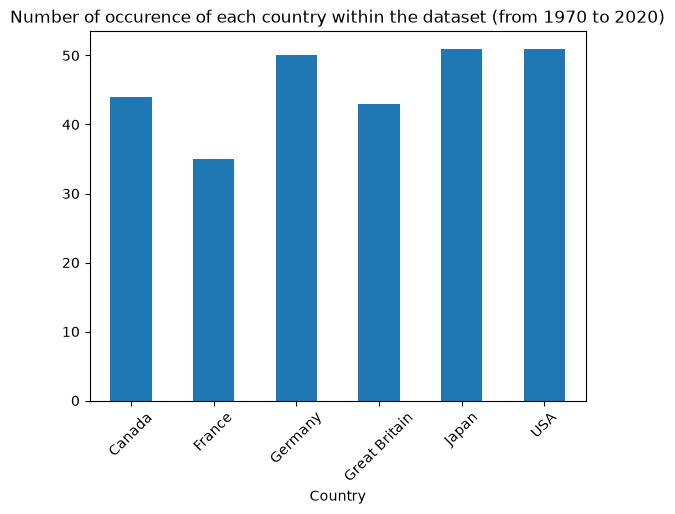

In [14]:
# Display the same graphic but organised by country 
df["Country"].value_counts().sort_index().plot(kind="bar", rot=45)
plt.title("Number of occurence of each country within the dataset (from 1970 to 2020)")
plt.show()

<Axes: xlabel='Country', ylabel='count'>

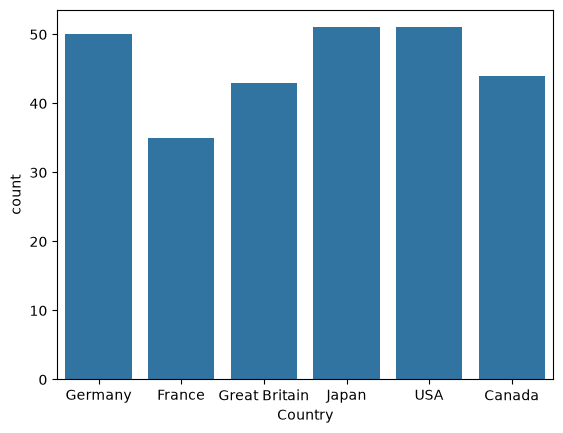

In [15]:
# Display the same graphic but made with seaborn
sns.countplot(data=df, x="Country")

<h3>3. <u>Analysez la variable "Spending_USD"</u></h3>

- Formulez dans une phrase claire ce que signifie la moyenne issue de cette analyse (Attention, soyez vraiment précis, c'est important)

- Réalisez les 2 graphiques utiles pour cette analyse


Ici, on a vu au début que `Spending_USD` représente la dépenses de santé par habitant exprimée en USD, pour chaque pays de notre dataset  (la France, les USA, le Canada, etc) 

Ainsi, `Spending_USD` est une variable continue, pour l'étudier on va faire une analyse univariée en cherchant à calculer des statistiques telles que : la moyenne, la médiane, la variance, l'écart-type, ...Pour cela, la fonction describe s'occupe déjà de tout.

In [ ]:
# Compute statistics  
df["Spending_USD"].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

Attention, quand on utilise cette fonction, on ne se contente pas de l'exécuter et de passer à la suite. On analyse nos résultats. 

Ici, on voit que :
- la moyenne est de 2789 USD (dollars, $) avec un écart type de 2194 USD. Cela doit nous interpeler. L'écart-type est du même ordre de grandeur que la moyenne. 
- la médiane (50%) est de 2295 USD. Elle est inférieure à la moyenne 
- on voit que la dépense la plus faible est de 123 USD. Quel pays cela concerne ? 

Ainsi, pour bien exprimer ce que représente notre moyenne dans cet exercice, on pourrait dire que :
- Les habitants de la France, les USA, le Canada, ... ont dépensé en moyenne 2789 USD par an de 1970 à 2020
- avec un écart type de 2194 USD
- ...

De plus, ce qu'il fait toujours faire quand on analyse une <span style="color:rgb(249, 116, 50)">variable</span> <span style="color:rgb(255, 215, 0)">continue</span>, en plus de calculer et d'analyser ses statistiques, c'est de créer des graphiques, comme les <span style="color:rgb(249, 116, 50)">histogrammes</span> et les <span style="color:rgb(249, 116, 50)">boxplots</span>. 

Pourquoi ? Parce qu'on peut avoir des statistiques qui nous trompent sur la vraie nature de nos données

<Axes: xlabel='Spending_USD', ylabel='Count'>

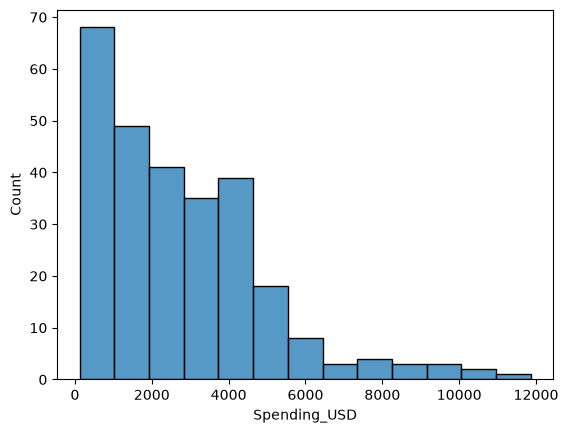

In [ ]:
# Build an histogram
sns.histplot(data=df, x="Spending_USD")

<Axes: xlabel='Spending_USD'>

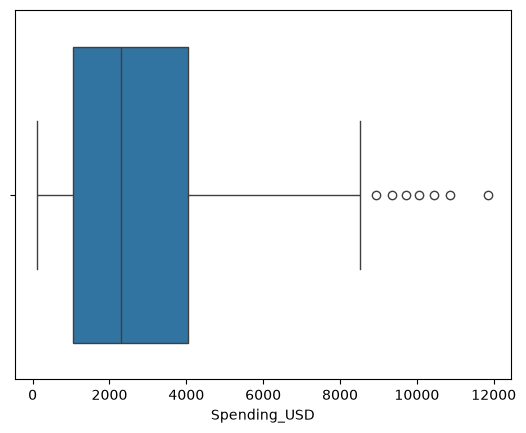

In [20]:
# Build a boxplot
sns.boxplot(data=df, x="Spending_USD")

Maintenant, on va chercher à les combiner pour mieux comprendre la distribution de nos données avec `sublots`. 

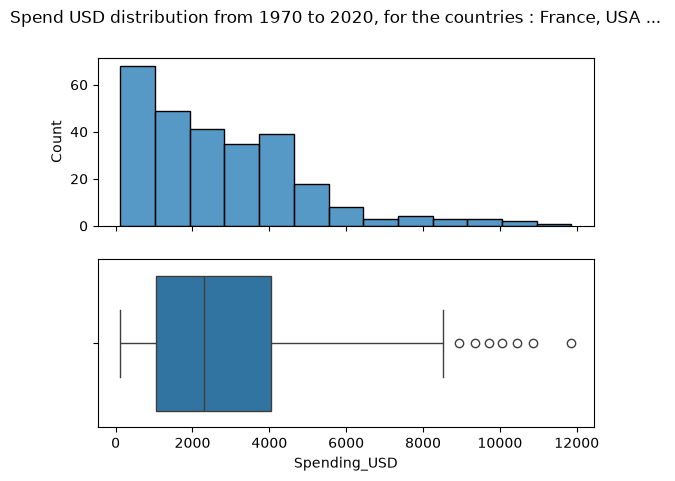

In [25]:
# Generate a graphic grid
fig, ax = plt.subplots(2, 1, sharex=True) # 2 rows and 1 column 
plt.suptitle("Spend USD distribution from 1970 to 2020, for the countries : France, USA ... ")
# Associate each graphic with a specific axe
sns.histplot(data=df, x="Spending_USD", ax=ax[0])
sns.boxplot(data=df, x="Spending_USD", ax=ax[1])
plt.show()

Remarque, ici on a ajouté le paramètre `sharex`, et on l'a configuré à `True`, afin que les axes $x$ des deux graphiques soient confondus/alignés. En effet, vu qu'ils représentent tous les deux la même variable, il est plus intéressant de bien aligner les données des deux graphiques sur cet axe $x$ commun. 

Cette représentation est super intéressante car on peut voir, où se situerait la médiane, où se situeraient les valeurs aberrantes, voir la délimitation des 75%. 

<h3>4. <u>Faire de même pour la variable "Life_Expectancy"</u></h3>


<h3>5. <u>Observez l'évolution de la durée de vie à travers le temps.</u></h3>


<h3>6. <u>Oups... Comment améliorer ce graphique ?</u></h3>


<h3>7. <u>Observez l'évolution des dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps.</u></h3>


<h3>8. <u>Observez l'histograme, la boxplot, et les statistiques de "Life_Expectancy" propre à chaque pays.</u></h3>


<h3>9. <u>Observez la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020</u></h3>


<h3>10. <u>Il y a une valeur aberrante tant tout cela. Laquelle? Pourquoi?</u></h3>